# Semiconductor Manufacturing Yield & Defect Trend Analysis using Python

# Loading the Dataset

In [1]:
import pandas as pd
data = pd.read_csv("secom.csv")
data.head()

,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


# Dataset Overview

In [2]:
# Shape of the dataset
data.shape

(1567, 592)

In [3]:
# Column names
data.columns

Index(['Time', '0', '1', '2', '3', '4', '5', '6', '7', '8',
       ...
       '581', '582', '583', '584', '585', '586', '587', '588', '589',
       'Pass/Fail'],
      dtype='object', length=592)

In [4]:
# Dataset information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 592 entries, Time to Pass/Fail
dtypes: float64(590), int64(1), object(1)
memory usage: 7.1+ MB


In [5]:
# Statistical summary
data.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
0,1561.0,3014.452896,73.621787,2743.2400,2966.2600,3011.4900,3056.6500,3356.3500
1,1560.0,2495.850231,80.407705,2158.7500,2452.2475,2499.4050,2538.8225,2846.4400
2,1553.0,2200.547318,29.513152,2060.6600,2181.0444,2201.0667,2218.0555,2315.2667
3,1553.0,1396.376627,441.691640,0.0000,1081.8758,1285.2144,1591.2235,3715.0417
4,1553.0,4.197013,56.355540,0.6815,1.0177,1.3168,1.5257,1114.5366
5,1553.0,100.000000,0.000000,100.0000,100.0000,100.0000,100.0000,100.0000
6,1553.0,101.112908,6.237214,82.1311,97.9200,101.5122,104.5867,129.2522
7,1558.0,0.121822,0.008961,0.0000,0.1211,0.1224,0.1238,0.1286
8,1565.0,1.462862,0.073897,1.1910,1.4112,1.4616,1.5169,1.6564
9,1565.0,-0.000841,0.015116,-0.0534,-0.0108,-0.0013,0.0084,0.0749


# Understanding the Target (Yield)

In [6]:
data['Pass/Fail'].value_counts()

Pass/Fail
-1    1463
 1     104
Name: count, dtype: int64

In [7]:
# Converting labels to readable format
data['Yield'] = data['Pass/Fail'].map({-1: 'Pass', 1: 'Fail'})
data.drop(columns=['Pass/Fail'], inplace=True)

In [8]:
data.head()

,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Yield
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,Pass
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,Pass
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,Fail
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,Pass
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,Pass


In [9]:
# Column names
data.columns

Index(['Time', '0', '1', '2', '3', '4', '5', '6', '7', '8',
       ...
       '581', '582', '583', '584', '585', '586', '587', '588', '589', 'Yield'],
      dtype='object', length=592)

# Missing Value Analysis

In [10]:
missing_percent = data.isna().mean() * 100
missing_percent.describe()

count    592.000000
mean       4.522219
std       15.410102
min        0.000000
25%        0.127632
50%        0.382897
75%        0.574346
max       91.193363
dtype: float64

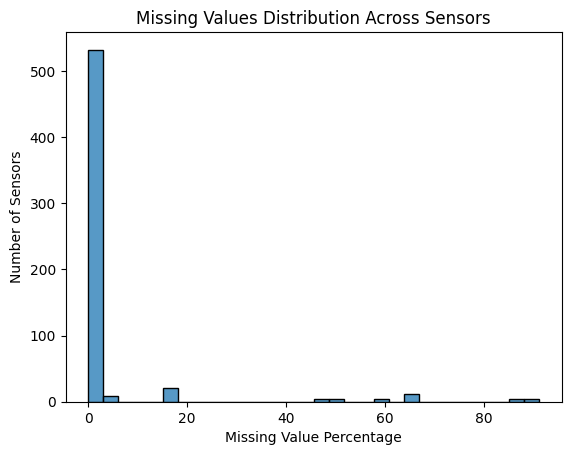

In [11]:
# Visualizing missing values distribution
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(missing_percent, bins=30)
plt.xlabel("Missing Value Percentage")
plt.ylabel("Number of Sensors")
plt.title("Missing Values Distribution Across Sensors")
plt.show()


# Data Cleaning & Preprocessing

In [12]:
# Remove sensors with > 60% missing values
valid_columns = missing_percent[missing_percent < 60].index
data_clean = data[valid_columns]
data_clean.shape

(1567, 568)

In [13]:
# Fill remaining missing values with median
data_clean = data_clean.fillna(data_clean.median(numeric_only=True))

# # Remove Constant / Non-Informative Sensors

In [14]:
constant_cols = data_clean.nunique() <= 1
data_clean = data_clean.loc[:, ~constant_cols]
data_clean.shape

(1567, 452)

# Yield Distribution Analysis

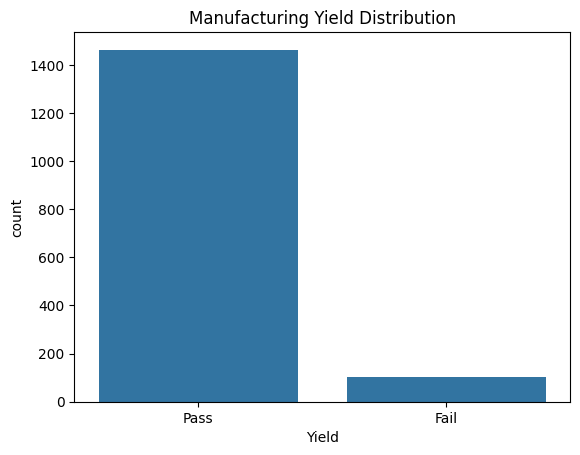

In [15]:
sns.countplot(data=data_clean, x='Yield')
plt.title("Manufacturing Yield Distribution")
plt.show()

In [16]:
data_clean['Yield'].value_counts(normalize=True) * 100

Yield
Pass    93.363114
Fail     6.636886
Name: proportion, dtype: float64

# Sensor Behavior vs Yield (Core Analysis)

In [17]:
# Selecting a small subset of sensors
sensor_columns = [col for col in data_clean.columns if col not in ['Time', 'Yield']]
selected_sensors = sensor_columns[:5]

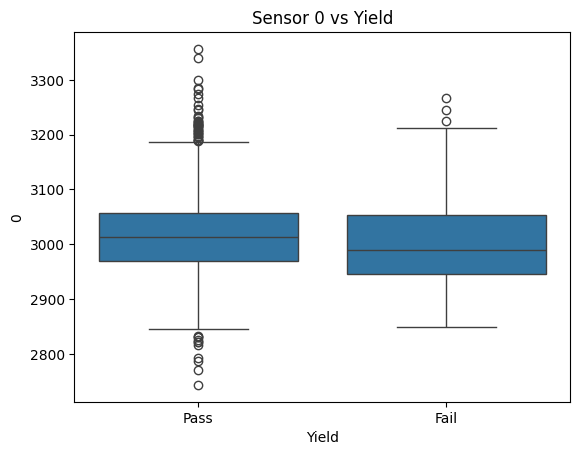

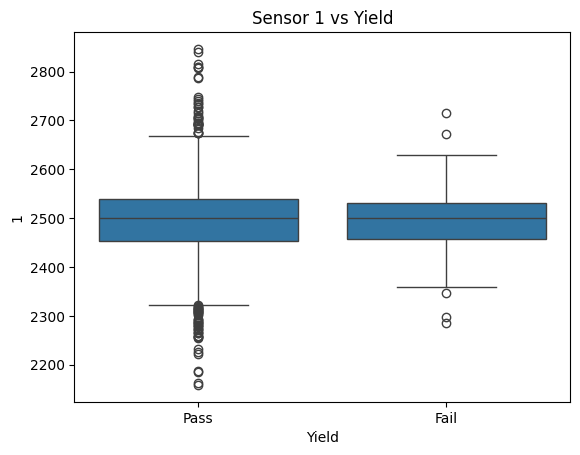

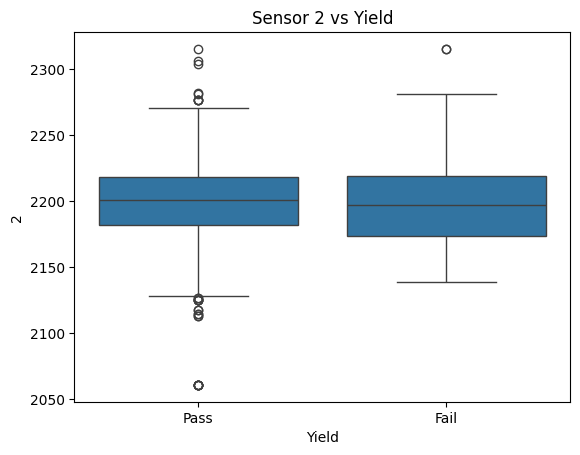

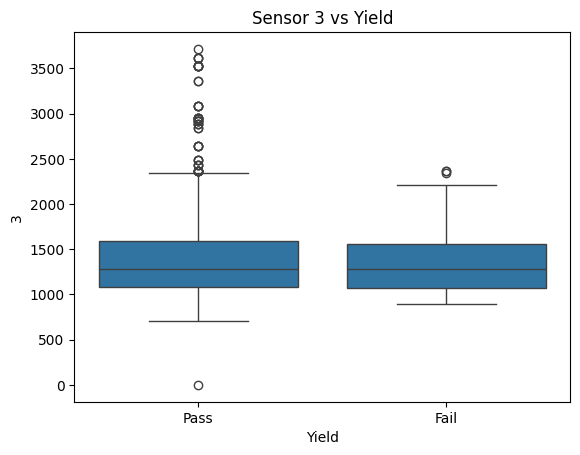

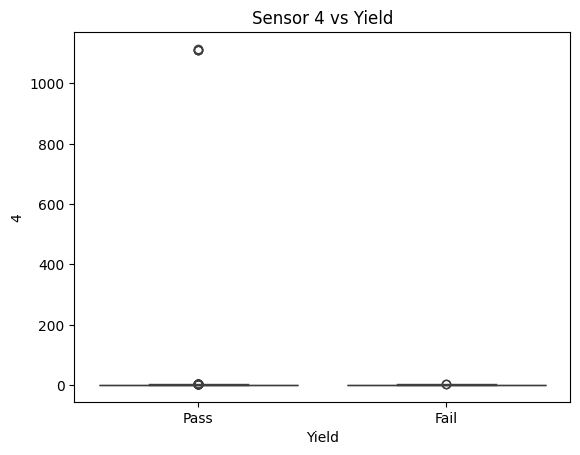

In [18]:
# Boxplots: Sensor values vs Yield
for col in selected_sensors:
    sns.boxplot(data=data_clean, x='Yield', y=col)
    plt.title(f"Sensor {col} vs Yield")
    plt.show()

# Trend Analysis Over Time

In [19]:
data_clean['Time'] = pd.to_datetime(data_clean['Time'])

In [20]:
yield_trend = data_clean.groupby(
    data_clean['Time'].dt.to_period('M')
)['Yield'].value_counts().unstack()

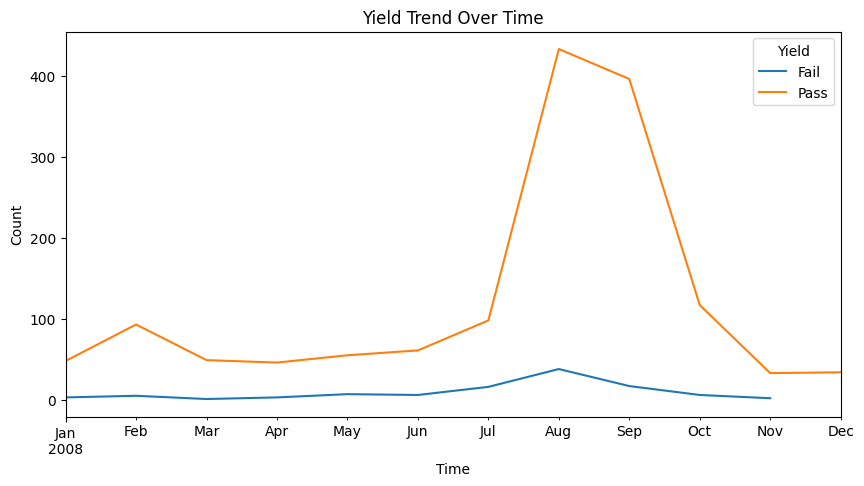

In [21]:
yield_trend.plot(kind='line', figsize=(10,5))
plt.title("Yield Trend Over Time")
plt.xlabel("Time")
plt.ylabel("Count")
plt.show()

# Correlation Analysis (Sensor Redundancy Detection)

In [22]:
corr_matrix = data_clean[selected_sensors].corr()

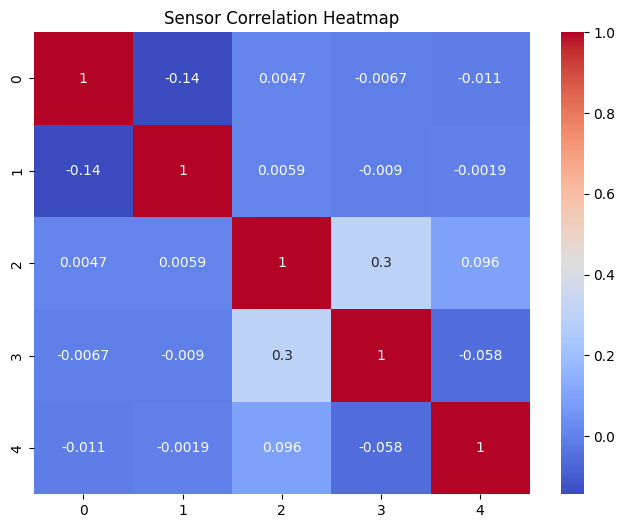

In [23]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True)
plt.title("Sensor Correlation Heatmap")
plt.show()